# Análise Exploratória — Credit Card Default

Visão rápida do dataset UCI Default of Credit Card Clients.

> Link: https://www.kaggle.com/datasets/uciml/default-of-credit-card-clients-dataset

- 30.000 clientes, 23 features, classificação binária
- Target: inadimplência no pagamento do cartão de crédito

In [1]:
import sys
sys.path.insert(0, "..")

import polars as pl
import matplotlib.pyplot as plt
from src.data import download_dataset

df = download_dataset()
print(f"Shape: ({df.height}, {df.width})")
print(f"\nDistribuição do target:")
counts = df["default"].value_counts().sort("default")
for row in counts.iter_rows(named=True):
    pct = row["count"] / df.height
    print(f"  {row['default']}: {row['count']} ({pct:.1%})")
df.head()

Shape: (30000, 24)

Distribuição do target:
  0: 23364 (77.9%)
  1: 6636 (22.1%)


LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_1,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default
f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64
20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


## Distribuição de Classes

Dataset desbalanceado (~22% default). Isso influencia a escolha de métricas (F1, ROC-AUC ao invés de acurácia).

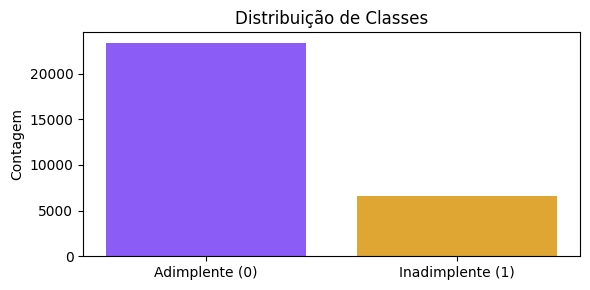

In [2]:
counts = df["default"].value_counts().sort("default")
fig, ax = plt.subplots(figsize=(6, 3))
ax.bar(
    ["Adimplente (0)", "Inadimplente (1)"],
    counts["count"].to_list(),
    color=["#8b5cf6", "#e0a633"],
)
ax.set_ylabel("Contagem")
ax.set_title("Distribuição de Classes")
plt.tight_layout()
plt.show()

## Features Mais Relevantes

Correlação com o target — features de histórico de pagamento são as mais preditivas.

In [3]:
import numpy as np

# Correlação com o target usando numpy
numeric_cols = [c for c in df.columns if c != "default"]
target = df["default"].to_numpy().astype(float)

correlations = {}
for col in numeric_cols:
    values = df[col].to_numpy().astype(float)
    correlations[col] = np.corrcoef(values, target)[0, 1]

corr_sorted = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)

print("Top 10 features por correlação com default:\n")
for feat, r in corr_sorted[:10]:
    print(f"  {feat:>12s}: {r:+.3f}")

Top 10 features por correlação com default:

         PAY_1: +0.325
         PAY_2: +0.264
         PAY_3: +0.235
         PAY_4: +0.217
         PAY_5: +0.204
         PAY_6: +0.187
     LIMIT_BAL: -0.154
      PAY_AMT1: -0.073
      PAY_AMT2: -0.059
      PAY_AMT4: -0.057


## Resumo

- Dataset com desbalanceamento moderado (~22% positivos)
- Features de pagamento (`PAY_1`, `PAY_2`, ...) são as mais correlacionadas com default
- Próximo passo: treinar modelos com grid search e comparar com testes de hipótese